# Exploration des données WADI

Ce notebook constitue l'**étape 1** du projet : l'Analyse Exploratoire des Données (EDA).  
L'objectif est de comprendre la structure du dataset avant de construire quoi que ce soit.

On va répondre à ces questions :
- Quelle est la forme et la période couverte par les données ?
- Y a-t-il des valeurs manquantes ?
- Comment se comporte la cible `1_LT_001_PV` (niveau du réservoir) ?
- Quelles variables sont les plus corrélées avec la cible ?

## 1. Imports

On importe les bibliothèques classiques pour la manipulation de données (`pandas`, `numpy`) et la visualisation (`matplotlib`, `seaborn`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Affichage des figures directement dans le notebook
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## 2. Chargement et parsing

On charge le CSV brut et on construit un index temporel propre en combinant les colonnes `Date` et `Time`.  
Toutes les colonnes sont converties en numérique — les valeurs non convertibles deviennent `NaN` (on les détectera dans la section suivante).

**Résultat attendu :** shape du dataframe, période couverte, durée totale.

In [2]:
df = pd.read_csv('WADI_14days_new.csv')
print(f"Shape brut : {df.shape}")

Shape brut : (784571, 130)


In [3]:
# Reconstruction du datetime depuis Row (1 Row = 1 seconde, continu, sans trou)
START_TIME = pd.Timestamp("2017-09-25 00:00:00")
df["datetime"] = START_TIME + pd.to_timedelta(df["Row"] - 1, unit="s")
df = df.sort_values("datetime").reset_index(drop=True)
df = df.set_index("datetime")
df = df.drop(columns=["Row", "Date", "Time"], errors="ignore")

# Conversion de toutes les colonnes en numérique
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Shape après parsing : {df.shape}")
print(f"Période : {df.index.min()} -> {df.index.max()}")
print(f"Durée   : {df.index.max() - df.index.min()}")

TARGET = "1_LT_001_PV"


Shape après parsing : (784571, 127)
Période : 2017-09-25 00:00:00 -> 2017-10-07 03:16:10
Durée   : 12 days 03:16:10


## 3. Valeurs manquantes

On identifie les colonnes incomplètes et leur taux de remplissage.  
- Les colonnes **à 100% vides** seront supprimées à l'étape de préprocessing (inutilisables).  
- Les colonnes avec **quelques NaN** seront imputées (interpolation ou forward-fill).

**Résultat attendu :** liste des colonnes manquantes avec leur pourcentage + graphique.

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['missing'] > 0].sort_values('pct', ascending=False)

print(f"Colonnes avec valeurs manquantes : {len(missing_df)}")
print(missing_df.to_string())

Colonnes avec valeurs manquantes : 8
                missing    pct
2_LS_001_AL      784571  100.0
2_LS_002_AL      784571  100.0
2_P_001_STATUS   784571  100.0
2_P_002_STATUS   784571  100.0
1_AIT_002_PV         12    0.0
1_AIT_004_PV          6    0.0
2B_AIT_004_PV        10    0.0
3_AIT_004_PV          6    0.0


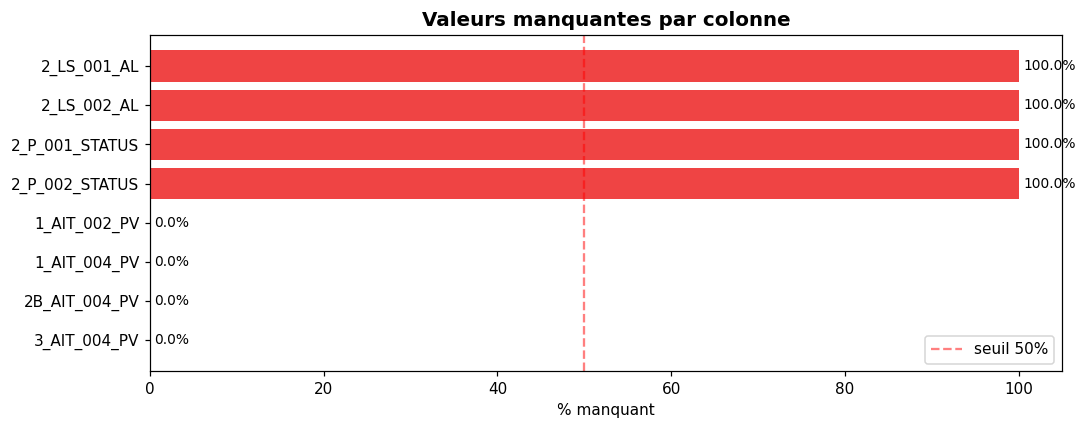

In [5]:
fig, ax = plt.subplots(figsize=(10, max(3, len(missing_df) * 0.5)))

colors = ['#EF4444' if p > 50 else '#F97316' if p > 10 else '#FACC15' for p in missing_df['pct']]
bars = ax.barh(missing_df.index[::-1], missing_df['pct'][::-1], color=colors[::-1])
ax.set_xlabel('% manquant')
ax.set_title('Valeurs manquantes par colonne', fontsize=13, fontweight='bold')
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='seuil 50%')
ax.legend()

for bar, val in zip(bars, missing_df['pct'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 4. Analyse de la variable cible : `1_LT_001_PV`

On examine la distribution et l'évolution temporelle du niveau du réservoir.  
- Les **statistiques descriptives** donnent les bornes min/max et la dispersion.  
- L'**histogramme** montre si la distribution est unimodale ou bimodale (cycles remplissage/vidange).  
- La **variation minute-à-minute** (Δ) indique la vitesse de changement — utile pour calibrer l'horizon de prédiction.

**Résultat attendu :** comprendre les plages de valeurs normales et la dynamique du signal.

In [6]:
print(f"=== Stats descriptives : {TARGET} ===")
print(df[TARGET].describe())

=== Stats descriptives : 1_LT_001_PV ===
count    784571.000000
mean         56.372290
std           8.845281
min          38.811800
25%          48.836800
50%          57.298200
75%          62.611000
max          71.619000
Name: 1_LT_001_PV, dtype: float64


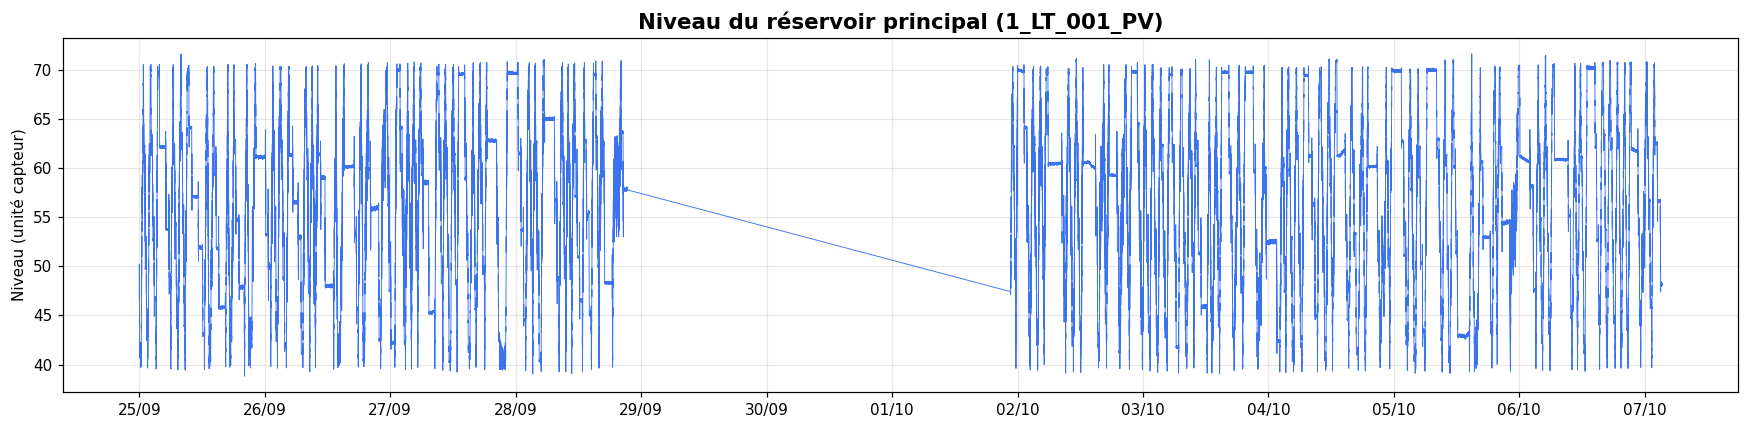

In [7]:
# Évolution temporelle complète de la cible
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df.index, df[TARGET], color='#2563EB', linewidth=0.6, alpha=0.9)
ax.set_title('Niveau du réservoir principal (1_LT_001_PV)', fontsize=14, fontweight='bold')
ax.set_ylabel('Niveau (unité capteur)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

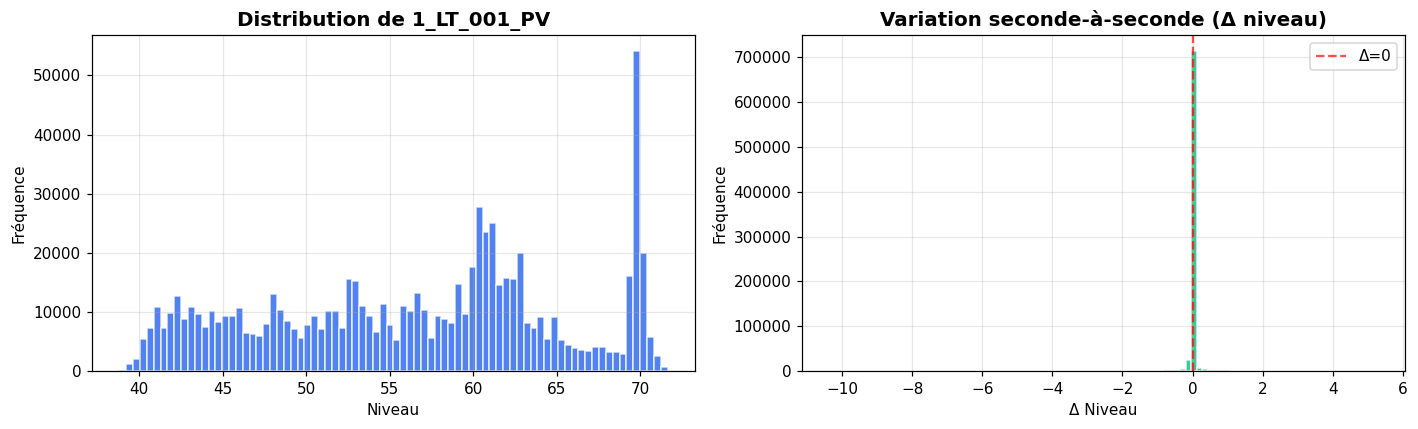

Variation max en 1 sec : +5.281 / -10.361
Variation moyenne abs  : 0.0533


In [9]:
# Distribution et variation minute-à-minute
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df[TARGET].dropna(), bins=80, color='#2563EB', alpha=0.8, edgecolor='white')
axes[0].set_title('Distribution de 1_LT_001_PV', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Niveau')
axes[0].set_ylabel('Fréquence')
axes[0].grid(True, alpha=0.3)

diff = df[TARGET].diff().dropna()
axes[1].hist(diff, bins=100, color='#10B981', alpha=0.8, edgecolor='white')
axes[1].set_title('Variation seconde-à-seconde (Δ niveau)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Δ Niveau')
axes[1].set_ylabel('Fréquence')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7, label='Δ=0')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Variation max en 1 sec : +{diff.max():.3f} / {diff.min():.3f}")
print(f"Variation moyenne abs  : {diff.abs().mean():.4f}")

## 5. Visualisation des variables clés

On superpose le niveau du réservoir avec les **débits** (FIT) et les **statuts de pompes** sur un zoom de 3 jours.  
L'objectif est de vérifier visuellement que ces variables sont bien liées à la cible — ce qui justifie leur inclusion dans les modèles.

**Résultat attendu :** voir si les variations de débit et les activations de pompes coïncident avec des changements de niveau.

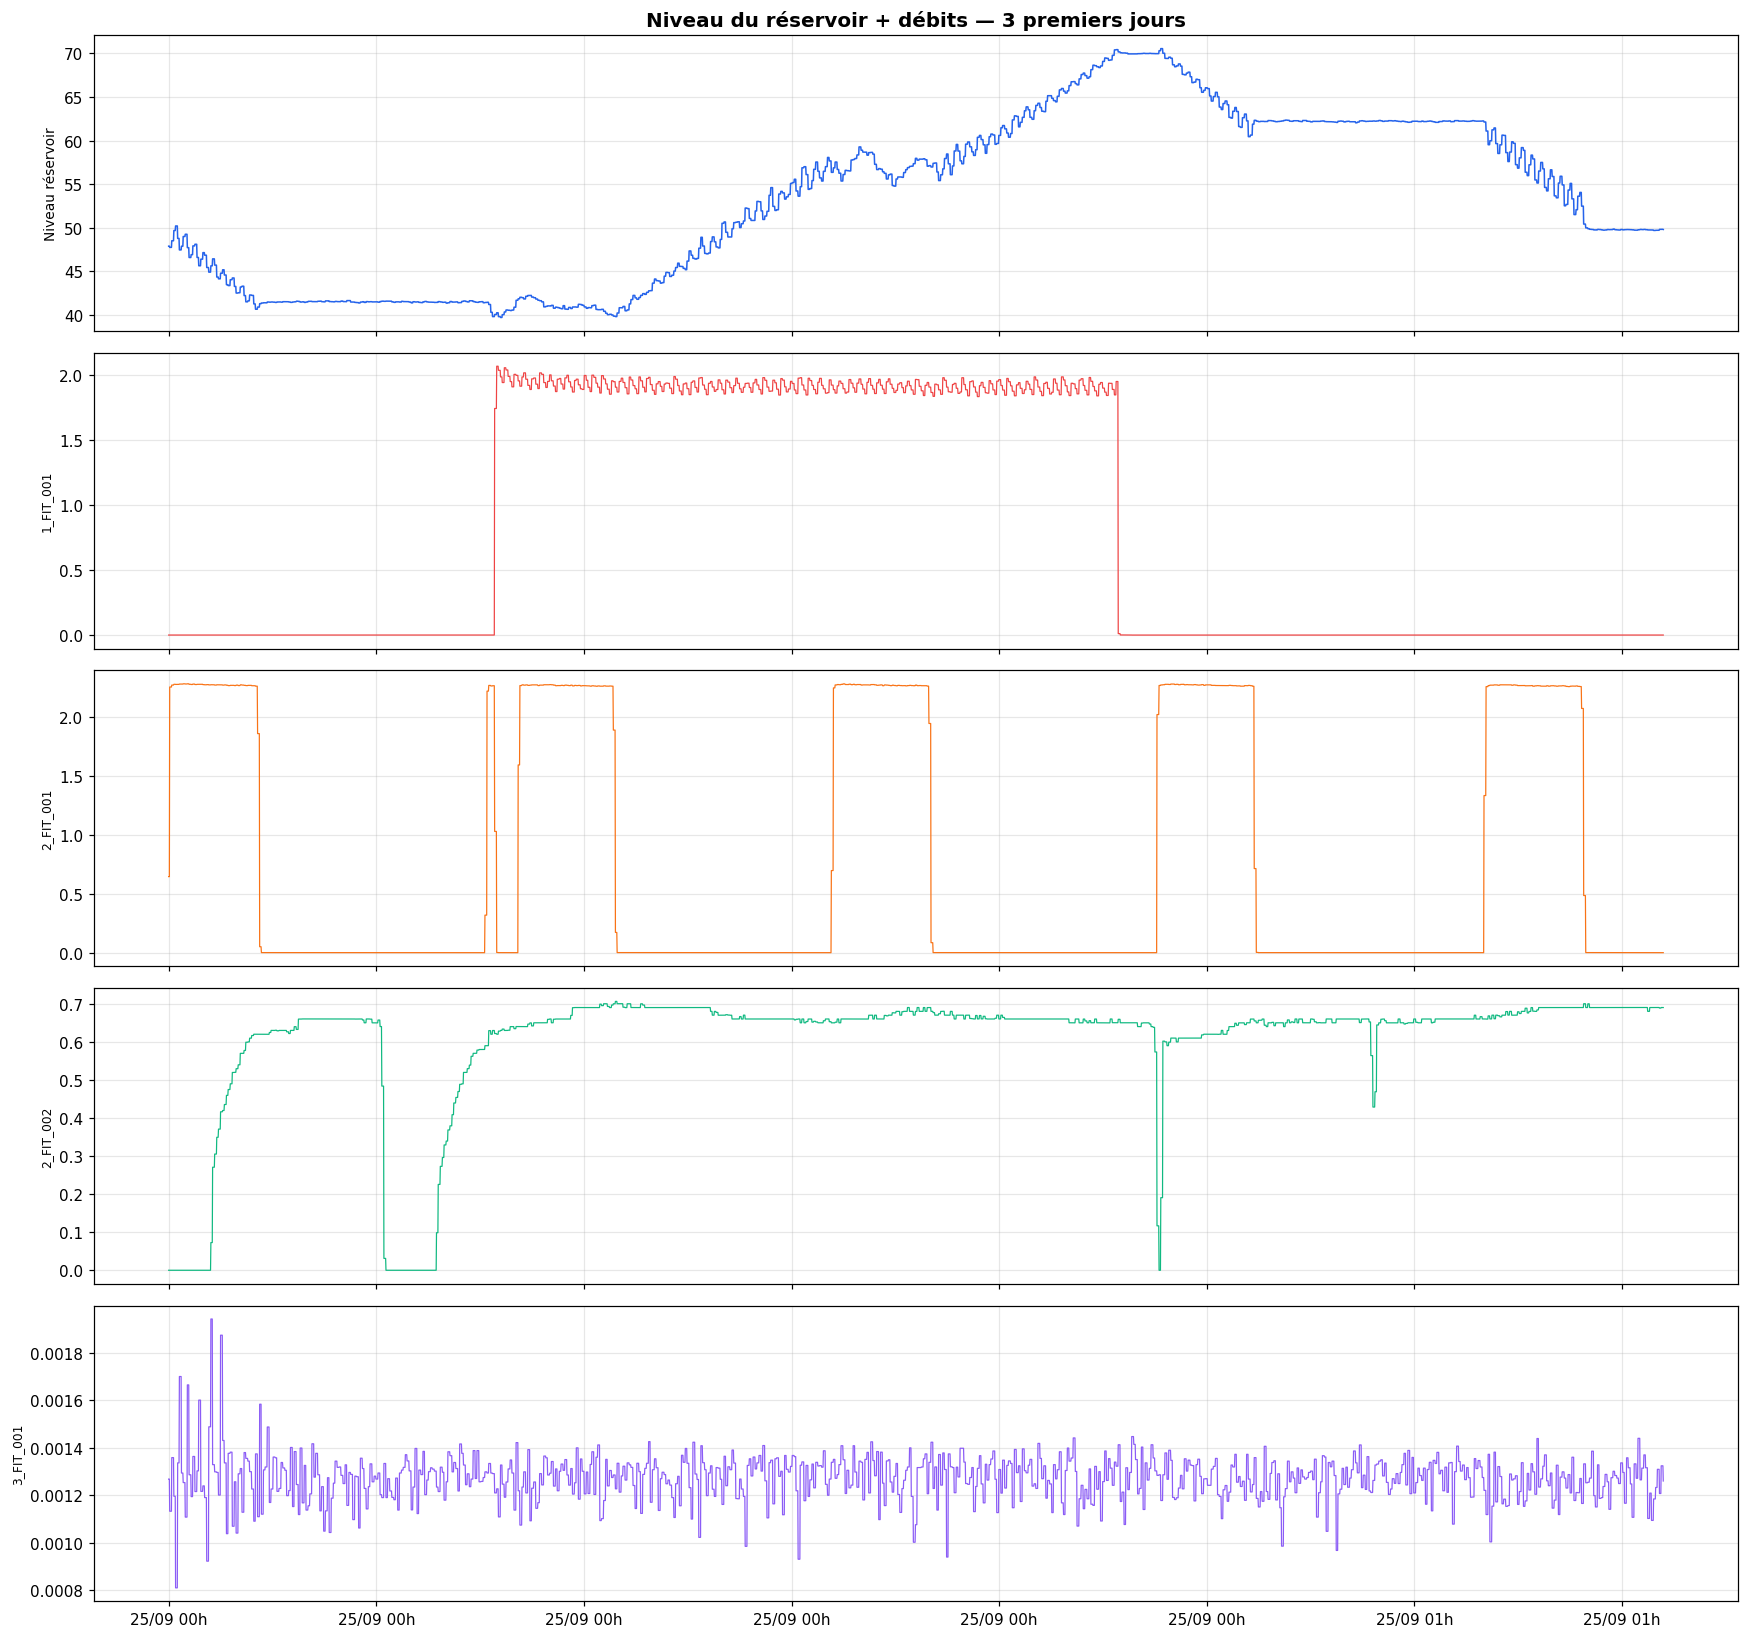

In [10]:
zoom = df.iloc[:3 * 1440]  # 3 premiers jours (1440 minutes/jour)
fit_cols = [c for c in ['1_FIT_001_PV', '2_FIT_001_PV', '2_FIT_002_PV', '3_FIT_001_PV'] if c in df.columns]

fig, axes = plt.subplots(len(fit_cols) + 1, 1, figsize=(16, 3 * (len(fit_cols) + 1)), sharex=True)

axes[0].plot(zoom.index, zoom[TARGET], color='#2563EB', linewidth=1)
axes[0].set_ylabel('Niveau réservoir', fontsize=9)
axes[0].set_title('Niveau du réservoir + débits — 3 premiers jours', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

colors_fit = ['#EF4444', '#F97316', '#10B981', '#8B5CF6']
for i, col in enumerate(fit_cols):
    axes[i + 1].plot(zoom.index, zoom[col], color=colors_fit[i], linewidth=0.8)
    axes[i + 1].set_ylabel(col.replace('_PV', ''), fontsize=8)
    axes[i + 1].grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %Hh'))
plt.tight_layout()
plt.show()

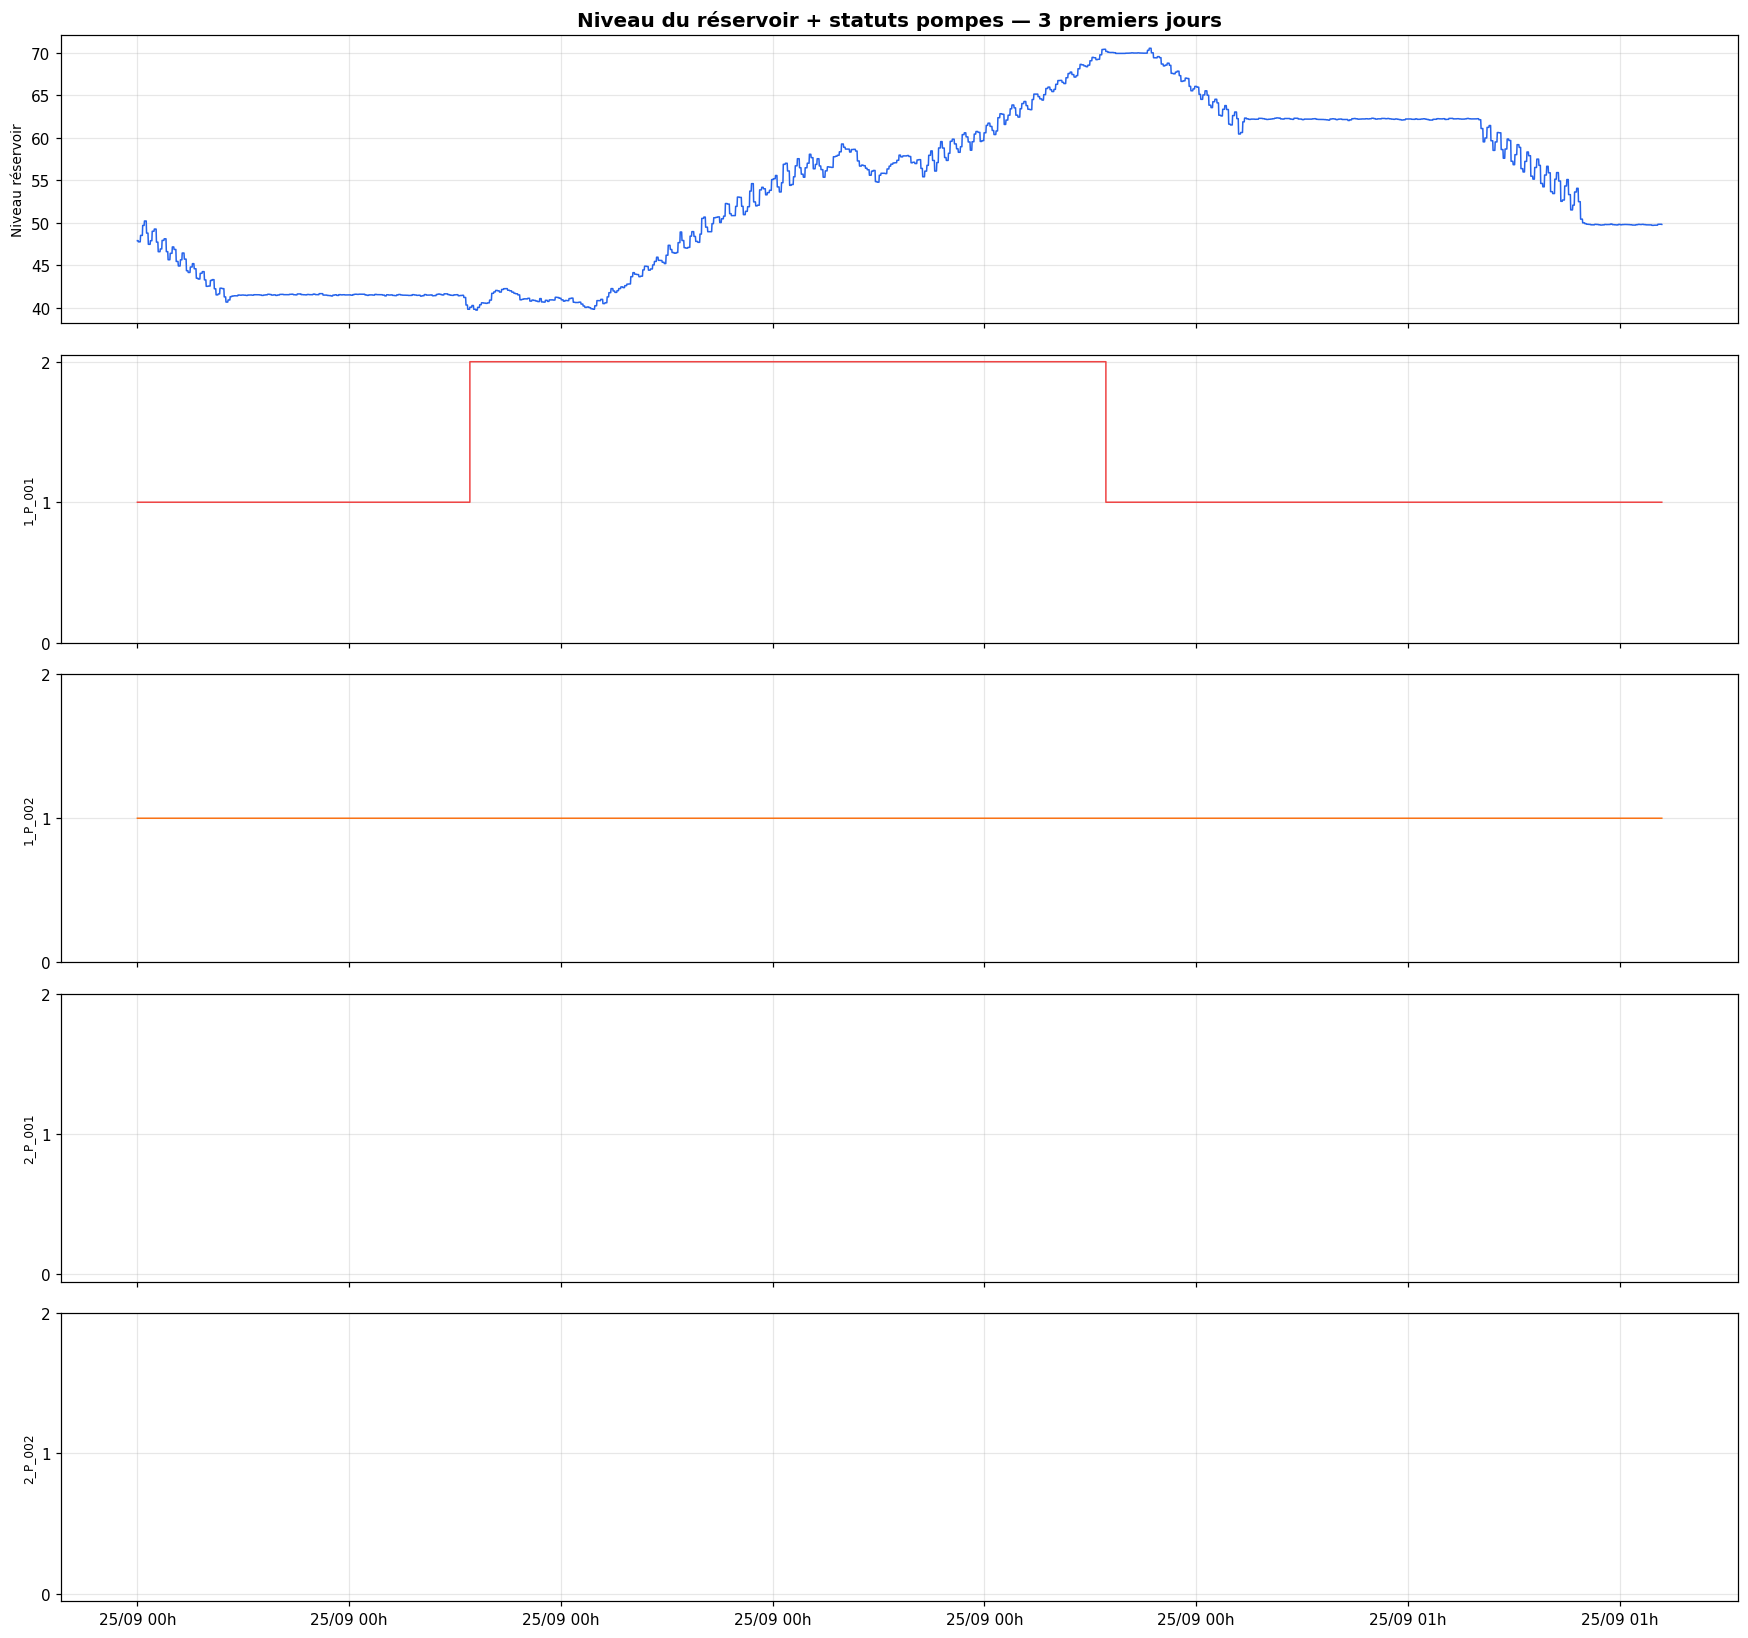

In [11]:
# Statuts des pompes — on utilise step() pour représenter les états discrets (0/1/2)
pump_cols = [c for c in ['1_P_001_STATUS', '1_P_002_STATUS', '2_P_001_STATUS', '2_P_002_STATUS'] if c in df.columns]

if pump_cols:
    fig, axes = plt.subplots(len(pump_cols) + 1, 1, figsize=(16, 3 * (len(pump_cols) + 1)), sharex=True)

    axes[0].plot(zoom.index, zoom[TARGET], color='#2563EB', linewidth=1)
    axes[0].set_ylabel('Niveau réservoir', fontsize=9)
    axes[0].set_title('Niveau du réservoir + statuts pompes — 3 premiers jours', fontsize=13, fontweight='bold')
    axes[0].grid(True, alpha=0.3)

    colors_p = ['#EF4444', '#F97316', '#10B981', '#8B5CF6']
    for i, col in enumerate(pump_cols):
        axes[i + 1].step(zoom.index, zoom[col], color=colors_p[i], linewidth=1, where='post')
        axes[i + 1].set_ylabel(col.replace('_STATUS', ''), fontsize=8)
        axes[i + 1].set_yticks([0, 1, 2])
        axes[i + 1].grid(True, alpha=0.3)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %Hh'))
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Aucune colonne de statut pompe disponible (toutes vides).")

## 6. Analyse des corrélations

On calcule les corrélations de Pearson entre les variables et la cible.  
- Une **corrélation élevée** (positive ou négative) indique qu'une variable est un bon prédicteur linéaire du niveau.  
- Une corrélation faible ne signifie pas forcément que la variable est inutile — les modèles non-linéaires (XGBoost, LSTM) peuvent exploiter des relations plus complexes.

**Résultat attendu :** identifier le top 20 des variables à prioriser dans le préprocessing.

In [12]:
# Corrélations sur les features clés définies dans le guide projet
KEY_FEATURES = [
    TARGET,
    '1_FIT_001_PV', '2_FIT_001_PV', '2_FIT_002_PV', '2_FIT_003_PV', '3_FIT_001_PV',
    '1_MV_001_STATUS', '1_MV_002_STATUS', '2_MV_001_STATUS',
    '1_P_001_STATUS', '1_P_002_STATUS', '2_P_001_STATUS', '2_P_002_STATUS',
    '2_FIC_101_SP', '2_FIC_101_PV', '2_FIC_101_CO',
]
KEY_FEATURES = [f for f in KEY_FEATURES if f in df.columns]

corr_key = df[KEY_FEATURES].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("=== Corrélations des features clés avec 1_LT_001_PV ===")
print(corr_key.to_string())

=== Corrélations des features clés avec 1_LT_001_PV ===
2_FIC_101_CO       0.168173
2_FIC_101_PV      -0.150404
1_MV_001_STATUS   -0.143070
1_FIT_001_PV      -0.142554
2_FIT_003_PV      -0.139867
1_P_001_STATUS    -0.139271
2_FIT_002_PV      -0.119422
2_FIT_001_PV      -0.118120
3_FIT_001_PV       0.094467
2_FIC_101_SP      -0.074571
1_MV_002_STATUS         NaN
2_MV_001_STATUS         NaN
1_P_002_STATUS          NaN
2_P_001_STATUS          NaN
2_P_002_STATUS          NaN


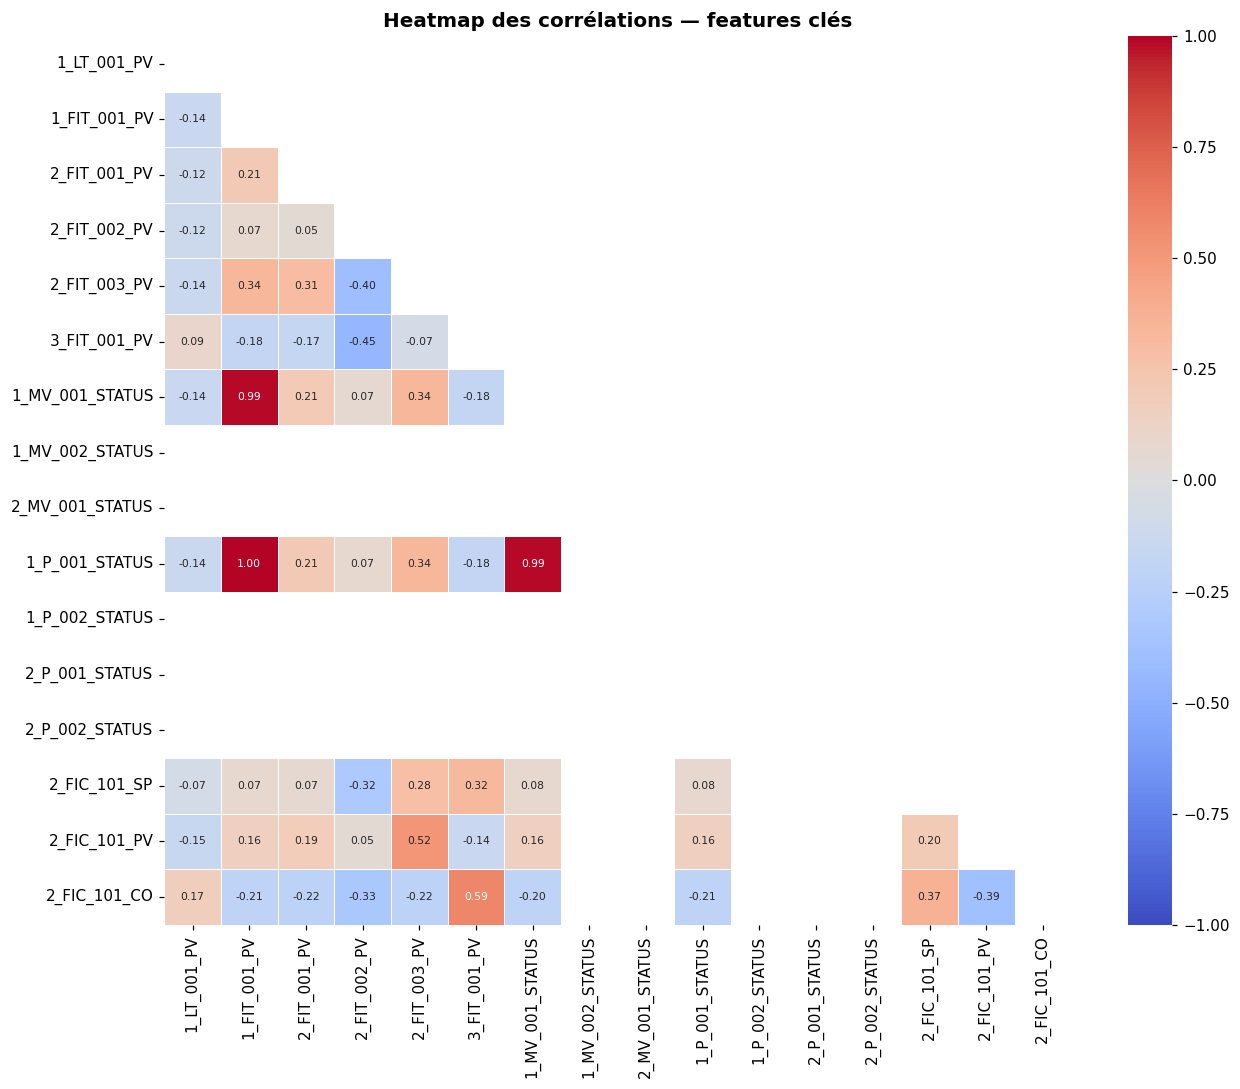

In [13]:
# Heatmap des corrélations entre toutes les features clés
corr_matrix = df[KEY_FEATURES].corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # masque triangle supérieur (redondant)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7}, vmin=-1, vmax=1)
ax.set_title('Heatmap des corrélations — features clés', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

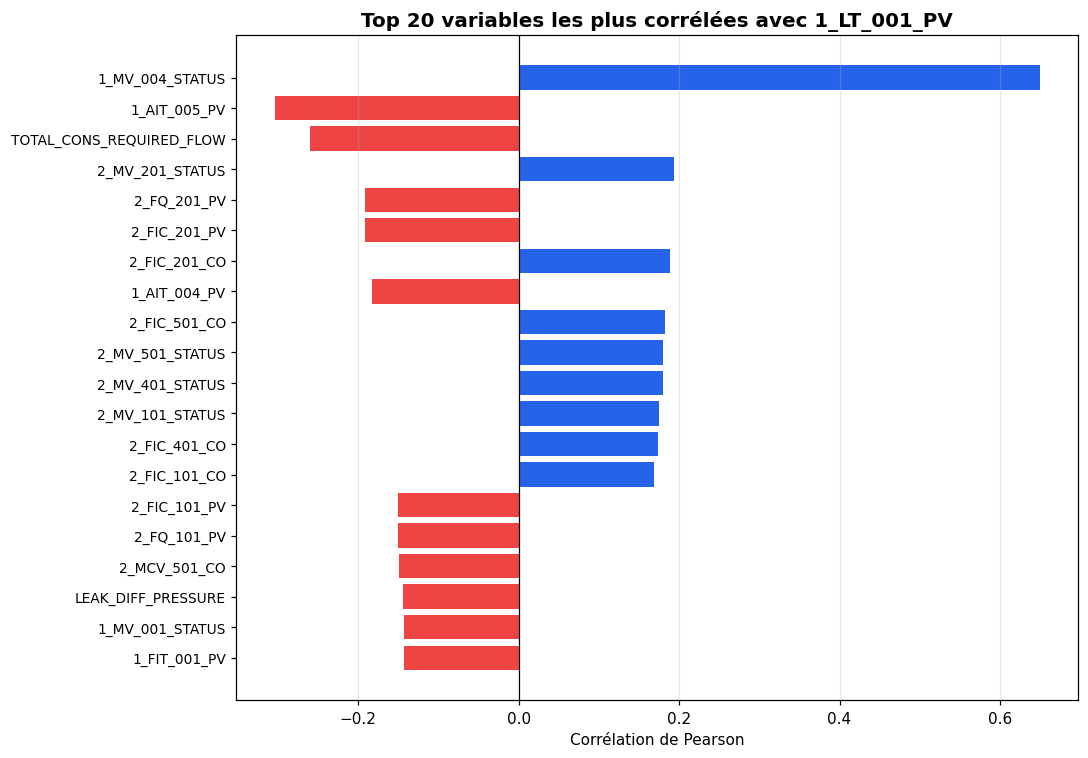


Top 5 (valeurs signées) :
1_MV_004_STATUS             0.649514
1_AIT_005_PV               -0.304016
TOTAL_CONS_REQUIRED_FLOW   -0.259707
2_MV_201_STATUS             0.193765
2_FQ_201_PV                -0.191185


In [14]:
# Top 20 sur l'ensemble des colonnes du dataset
all_corr = df.corr()[TARGET].drop(TARGET).dropna()
top_corr = all_corr.abs().sort_values(ascending=False).head(20)
top_corr_signed = all_corr[top_corr.index]  # valeurs signées pour l'affichage

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = ['#EF4444' if v < 0 else '#2563EB' for v in top_corr_signed]
ax.barh(range(len(top_corr_signed)), top_corr_signed.values[::-1], color=colors_bar[::-1])
ax.set_yticks(range(len(top_corr_signed)))
ax.set_yticklabels(top_corr_signed.index[::-1], fontsize=9)
ax.set_xlabel('Corrélation de Pearson')
ax.set_title('Top 20 variables les plus corrélées avec 1_LT_001_PV', fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nTop 5 (valeurs signées) :")
print(top_corr_signed.head(5).to_string())

## 7. Résumé de l'EDA

On affiche un bilan complet du dataset pour avoir une vue d'ensemble avant de passer au préprocessing.

In [15]:
print("✅ Résumé EDA")
print(f"  Lignes       : {len(df):,}")
print(f"  Colonnes     : {df.shape[1]}")
print(f"  Période      : {df.index.min().strftime('%d/%m/%Y')} → {df.index.max().strftime('%d/%m/%Y')}")
print(f"  Cols vides   : {(df.isnull().mean() == 1).sum()} (à supprimer)")
print(f"  Cols quasi-ok: {((df.isnull().mean() > 0) & (df.isnull().mean() < 1)).sum()} (quelques NaN, à imputer)")
print()
print(f"  Cible {TARGET} :")
print(f"    min  = {df[TARGET].min():.2f}")
print(f"    max  = {df[TARGET].max():.2f}")
print(f"    mean = {df[TARGET].mean():.2f}")
print(f"    std  = {df[TARGET].std():.2f}")
print()
print("  → Prochaine étape : préprocessing (suppression colonnes vides, normalisation, création des lags)")

✅ Résumé EDA
  Lignes       : 784,571
  Colonnes     : 127
  Période      : 25/09/2017 → 07/10/2017
  Cols vides   : 4 (à supprimer)
  Cols quasi-ok: 4 (quelques NaN, à imputer)

  Cible 1_LT_001_PV :
    min  = 38.81
    max  = 71.62
    mean = 56.37
    std  = 8.85

  → Prochaine étape : préprocessing (suppression colonnes vides, normalisation, création des lags)
